In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow, RBM
from detnqs.vstate import SelectedState, ExactState
from detnqs.driver import VMC
from detnqs.optimizer import sr, minsr, adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

def hf_det(n_alpha: int, n_beta: int, *, nword: int = 1) -> np.ndarray:
    det = np.zeros((1, 2, nword), dtype=np.uint64)
    for i in range(n_alpha):
        det[0, 0, i >> 6] |= np.uint64(1) << np.uint64(i & 63)
    for i in range(n_beta):
        det[0, 1, i >> 6] |= np.uint64(1) << np.uint64(i & 63)
    return det

def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

In [2]:
mol = gto.M(
    atom=
    '''
    O   0.00000000,  0.00000000,  0.00000000
    H   0.75700000,  0.00000000,  0.58590000
    H  -0.75700000,  0.00000000,  0.58590000
    ''',
    basis="sto-3g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,))
# model = RBM(norb=norb, alpha=1)

SCF energy : -74.962934879059
FCI energy : -75.012416346077
S^2  : 0.000000


E0531 02:12:55.374640   20488 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0531 02:12:55.382260   20361 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


step=   0  energy=-74.96191304  variance= 0.11875809  
         times: backward= 0.0089 | forward= 0.0028 | optimizer= 0.0725 | reduce= 0.0002 | total= 0.0845
step=  10  energy=-75.01194782  variance= 0.00130349  
         times: backward= 0.0090 | forward= 0.0028 | optimizer= 0.0727 | reduce= 0.0001 | total= 0.0847
step=  20  energy=-75.01239883  variance= 0.00012457  
         times: backward= 0.0093 | forward= 0.0028 | optimizer= 0.0733 | reduce= 0.0001 | total= 0.0856
step=  30  energy=-75.01241235  variance= 0.00005209  
         times: backward= 0.0076 | forward= 0.0025 | optimizer= 0.0729 | reduce= 0.0001 | total= 0.0832
step=  40  energy=-75.01241448  variance= 0.00002787  
         times: backward= 0.0076 | forward= 0.0024 | optimizer= 0.0727 | reduce= 0.0001 | total= 0.0829
step=  50  energy=-75.01241525  variance= 0.00001671  
         times: backward= 0.0076 | forward= 0.0026 | optimizer= 0.0722 | reduce= 0.0001 | total= 0.0826
step=  60  energy=-75.01241563  variance= 0.00

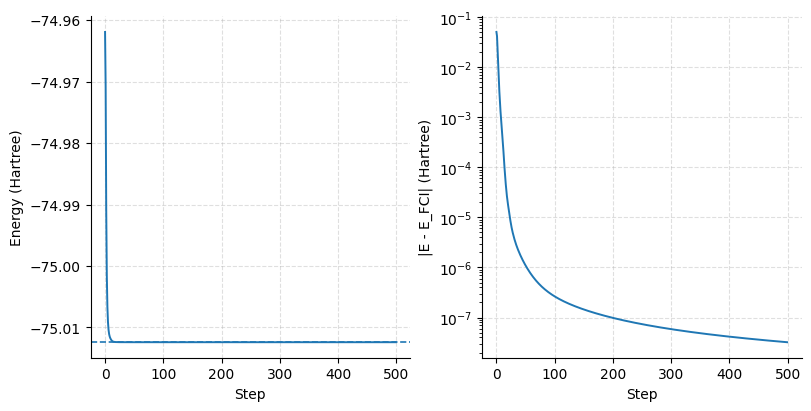

In [3]:
state = ExactState.init(
    model=model,
    hamiltonian=ham,
    n_alpha=n_alpha,
    n_beta=n_beta,
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []
steps = 500

for step in range(steps):
    history.append(vmc.step()["energy"]) 
    stats = vmc.step()
    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:4d}  "
            f"energy={history[-1]: .8f}  "
            f"variance={stats['variance']: .8f}  "
        )
        time_items = sorted(
            (k[5:], float(stats[k])) for k in stats if k.startswith("time_")
        )
        if time_items:
            line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
            print(f"         times: " + line)
    
plot_convergence(history, e_fci)
plt.show()

outer= 0  energy=-75.01147185  variance= 0.00000228  n_v=   41
         times: backward= 0.8167 | forward= 0.2693 | optimizer= 1.8681 | reduce= 0.0096 | total= 2.9714
outer= 1  energy=-75.01241379  variance= 0.00005424  n_v=  128
         times: backward= 0.8282 | forward= 0.3283 | optimizer= 1.2087 | reduce= 0.0099 | total= 2.3832
outer= 2  energy=-75.01241569  variance= 0.00001807  n_v=  128
         times: backward= 0.7885 | forward= 0.2683 | optimizer= 1.2182 | reduce= 0.0102 | total= 2.2943
outer= 3  energy=-75.01241599  variance= 0.00000966  n_v=  128
         times: backward= 0.7652 | forward= 0.2502 | optimizer= 1.1146 | reduce= 0.0100 | total= 2.1472
outer= 4  energy=-75.01241613  variance= 0.00000535  n_v=  128
         times: backward= 0.7636 | forward= 0.2483 | optimizer= 1.0896 | reduce= 0.0097 | total= 2.1183


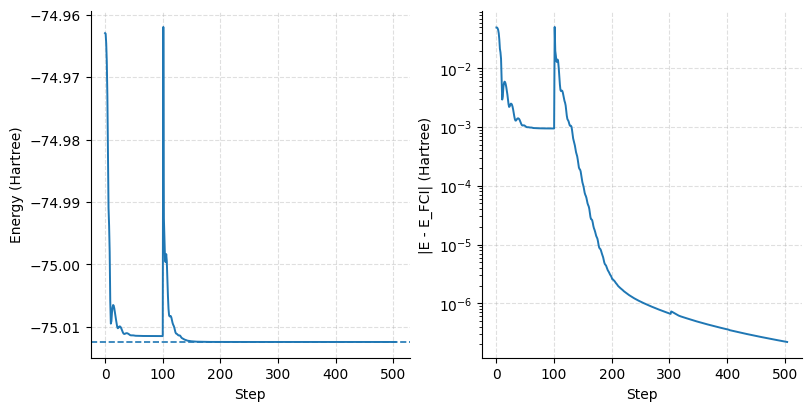

In [4]:
from detnqs.vstate.selected import topk_selector

state = SelectedState.init(
    model=model,
    hamiltonian=ham,
    init_v=hf_det(n_alpha, n_beta),
    key=jax.random.key(0),
)

vmc = VMC.init(state, optax.adamw(1e-3), geometry=False)

history   = []
outer_steps = 5
inner_steps = 100

for outer in range(outer_steps):
    state = vmc.state
    state = state.evolve(topk_selector(k=128), eps=1e-6)
    vmc.state = state

    times = {
        "time_forward": 0.0,
        "time_reduce": 0.0,
        "time_backward": 0.0,
        "time_total": 0.0,
        "time_optimizer": 0.0,
    }

    for inner in range(inner_steps):
        stats = vmc.step()
        history.append(float(stats["energy"]))
        for k in times:
            times[k] += float(stats.get(k, 0.0))
            
    stats = vmc.step()
    history.append(float(stats["energy"]))
    for k in times:
        times[k] += float(stats.get(k, 0.0))
        
    stats = dict(stats)
    stats.update(times)
    
    print(
        f"outer={outer:2d}  "
        f"energy={stats['energy']: .8f}  "
        f"variance={stats['variance']: .8f}  "
        f"n_v={vmc.state.n_v:5d}"
    )

    time_items = sorted(
        (k[5:], float(v))
        for k, v in stats.items()
        if k.startswith("time_")
    )

    if time_items:
        line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
        print(f"         times: {line}")

plot_convergence(history, e_fci)
plt.show()